In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

output_dir = Path(os.environ.get("OUTPUT_DATA_DIR", "../output_data")).resolve()

df_per_subject = pd.read_csv(output_dir / "cneuromod_tidy_per_subject.csv")
df_total = pd.read_csv(output_dir / "cneuromod_tidy_total.csv")

pivot_per_subject = df_per_subject.pivot_table(index="dataset", columns="dotpath", values="value", aggfunc="first")
pivot_total = df_total.pivot_table(index="dataset", columns="dotpath", values="value", aggfunc="first")
datasets_list = df_per_subject["dataset"].unique().tolist()

print(f"Loaded {len(datasets_list)} CNeuroMod dataset(s)")

Loaded 3 CNeuroMod dataset(s)


In [2]:
COLUMN_GROUPS_PER_SUBJECT = [
    ("Neuroimaging", "#4472C4", [
        ("fMRI",  "neuroimaging.fmri.per_subject_h",  "h"),
        ("EEG",   "neuroimaging.eeg.per_subject_h",   "h"),
        ("MEG",   "neuroimaging.meg.per_subject_h",   "h"),
        ("iEEG",  "neuroimaging.ieeg.per_subject_h",  "h"),
    ]),
    ("Stimuli", "#538135", [
        ("Images", "naturalistic_stimuli.images.per_subject_unique",           "#img"),
        ("Video",  "naturalistic_stimuli.video.per_subject_unique",            "h"),
        ("Audio",  "naturalistic_stimuli.audio.per_subject_unique",            "h"),
        ("Speech", "naturalistic_stimuli.speech_listening.per_subject_unique", "h"),
        ("Text",   "naturalistic_stimuli.text_reading.per_subject_unique",     "h"),
        ("Rest",   "naturalistic_stimuli.resting_state.per_subject_unique",    "h"),
    ]),
    ("Responses", "#C55A11", [
        ("Tasks", "responses.controlled_tasks.per_subject_unique", "#cond"),
        ("Games", "responses.game_actions.per_subject_unique",     "h"),
    ]),
    ("Physiology", "#7030A0", [
        ("ECG",   "physiology.ecg.per_subject_h",            "h"),
        ("Resp.", "physiology.respiration.per_subject_h",    "h"),
        ("PPG",   "physiology.plethysmograph.per_subject_h", "h"),
        ("EDA",   "physiology.eda.per_subject_h",            "h"),
        ("Eye",   "physiology.eye_tracking.per_subject_h",   "h"),
    ]),
]

COLUMN_GROUPS_TOTAL = [
    ("Neuroimaging", "#4472C4", [
        ("fMRI",  "neuroimaging.fmri.total_h",  "h"),
        ("EEG",   "neuroimaging.eeg.total_h",   "h"),
        ("MEG",   "neuroimaging.meg.total_h",   "h"),
        ("iEEG",  "neuroimaging.ieeg.total_h",  "h"),
    ]),
    ("Stimuli", "#538135", [
        ("Images", "naturalistic_stimuli.images.total_unique",           "#img"),
        ("Video",  "naturalistic_stimuli.video.total_unique",            "h"),
        ("Audio",  "naturalistic_stimuli.audio.total_unique",            "h"),
        ("Speech", "naturalistic_stimuli.speech_listening.total_unique", "h"),
        ("Text",   "naturalistic_stimuli.text_reading.total_unique",     "h"),
        ("Rest",   "naturalistic_stimuli.resting_state.total_unique",    "h"),
    ]),
    ("Responses", "#C55A11", [
        ("Tasks", "responses.controlled_tasks.total_unique", "#cond"),
        ("Games", "responses.game_actions.total_unique",     "h"),
    ]),
    ("Physiology", "#7030A0", [
        ("ECG",   "physiology.ecg.total_h",            "h"),
        ("Resp.", "physiology.respiration.total_h",    "h"),
        ("PPG",   "physiology.plethysmograph.total_h", "h"),
        ("EDA",   "physiology.eda.total_h",            "h"),
        ("Eye",   "physiology.eye_tracking.total_h",   "h"),
    ]),
]

HOUR_TIERS = [
    (20 / 60,      200,  5.5, "ultra small\n(<20 min)"),
    (1,            500,  6.5, "small\n(<1 h)"),
    (10,          1000,  7.5, "medium\n(<10 h)"),
    (50,          2000,  8.5, "big\n(<50 h)"),
    (float("inf"), 3500, 9.5, "ultra big\n(\u226550 h)"),
]
IMAGE_TIERS = [
    (1000,         500,  6.5, "small\n(<1k)"),
    (5000,        1000,  7.5, "medium\n(<5k)"),
    (10000,       2000,  8.5, "big\n(<10k)"),
    (float("inf"), 3500, 9.5, "ultra big\n(\u226510k)"),
]
COND_TIERS = [
    (10,           500,  6.5, "small\n(<10)"),
    (100,         1000,  7.5, "medium\n(<100)"),
    (500,         2000,  8.5, "big\n(<500)"),
    (float("inf"), 3500, 9.5, "ultra big\n(\u2265500)"),
]

TIER_MAP = {"h": HOUR_TIERS, "#img": IMAGE_TIERS, "#cond": COND_TIERS}


def value_to_bubble(value, unit):
    for upper, s, fs, _ in TIER_MAP[unit]:
        if value < upper:
            return s, fs
    return TIER_MAP[unit][-1][1], TIER_MAP[unit][-1][2]


def fmt(value, unit):
    if unit in ("#img", "#cond"):
        return f"{value / 1000:.1f}k" if value >= 1000 else str(int(value))
    if value >= 10:
        return f"{value:.0f}h"
    if value >= 1:
        return f"{value:.1f}h"
    return f"{value * 60:.0f}m"


def make_bubble_chart(column_groups, pivot, datasets_list, title, out_path):
    all_cols = []
    group_spans = []
    for group_name, color, fields in column_groups:
        start = len(all_cols)
        for label, path, unit in fields:
            all_cols.append((label, path, unit, color))
        group_spans.append((group_name, color, start, len(all_cols) - 1))
    n_cols = len(all_cols)

    fmri_col = next((p for _, p, _, _ in all_cols if "fmri" in p and "per_subject" in p), None)
    if fmri_col and fmri_col in pivot.columns:
        fmri_hours = pivot[fmri_col]
        datasets_sorted = sorted(datasets_list, key=lambda d: fmri_hours.get(d, 0) or 0, reverse=True)
    else:
        datasets_sorted = sorted(datasets_list)
    n_ds = len(datasets_sorted)

    COL_W, ROW_H = 0.78, 0.80
    LABEL_W = 3.2
    HEADER_H = 1.6

    fig, ax = plt.subplots(figsize=(LABEL_W + n_cols * COL_W, HEADER_H + n_ds * ROW_H))

    for gname, color, c0, c1 in group_spans:
        ax.axvspan(c0 - 0.5, c1 + 0.5, color=color, alpha=0.07, zorder=0)

    for gname, color, c0, c1 in group_spans:
        ax.text((c0 + c1) / 2, n_ds + 0.55, gname,
                ha="center", va="center", fontsize=11, fontweight="bold", color=color)

    ax.set_xticks(range(n_cols))
    ax.set_xticklabels([c[0] for c in all_cols], rotation=45, ha="right", fontsize=9)
    for tick, (_, _, _, color) in zip(ax.get_xticklabels(), all_cols):
        tick.set_color(color)

    for row_i, ds_name in enumerate(datasets_sorted):
        y = n_ds - 1 - row_i
        ax.text(-0.52, y, ds_name, ha="right", va="center", fontsize=9)
        for col_j, (label, path, unit, color) in enumerate(all_cols):
            if path not in pivot.columns:
                continue
            value = pivot.loc[ds_name, path]
            if pd.isna(value) or value == 0:
                continue
            s, fs = value_to_bubble(value, unit)
            ax.scatter(col_j, y, s=s, color=color, alpha=0.75, linewidths=0, zorder=3)
            ax.text(col_j, y, fmt(value, unit),
                    ha="center", va="center", fontsize=fs, fontweight="bold",
                    color="white", zorder=4)

    ax.set_yticks([])
    ax.set_xlim(-0.5, n_cols - 0.5)
    ax.set_ylim(-0.55, n_ds + 1.0)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.grid(axis="x", linestyle=":", alpha=0.35, zorder=1)
    ax.set_title(title, fontsize=13, fontweight="bold", pad=10)

    plt.tight_layout()
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved {out_path.name}")

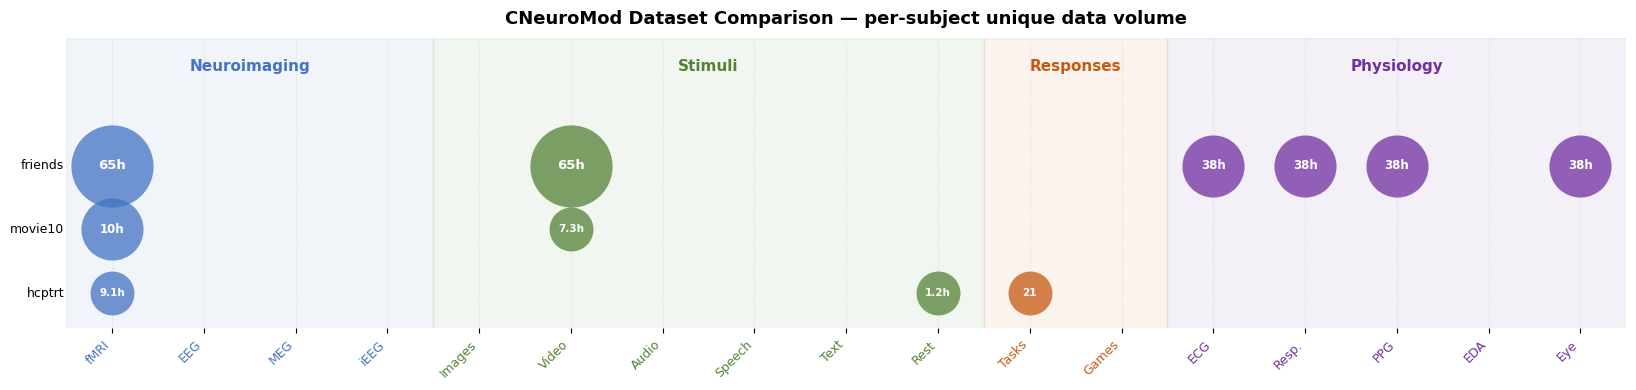

Saved cneuromod_comparison_per_subject.png


In [3]:
make_bubble_chart(
    COLUMN_GROUPS_PER_SUBJECT,
    pivot_per_subject,
    datasets_list,
    "CNeuroMod Dataset Comparison — per-subject unique data volume",
    output_dir / "cneuromod_comparison_per_subject.png",
)

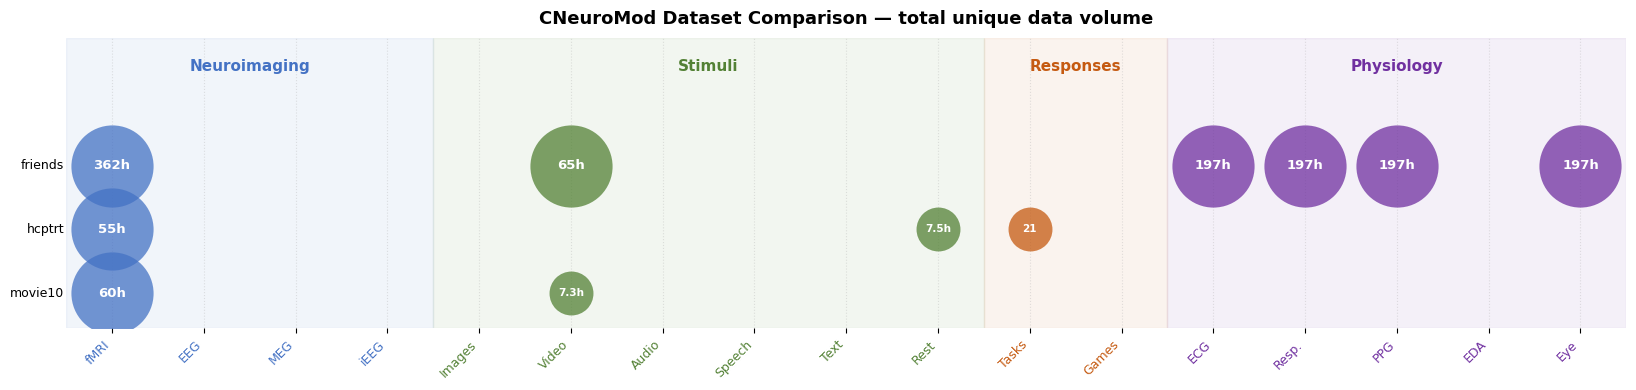

Saved cneuromod_comparison_total.png


In [4]:
make_bubble_chart(
    COLUMN_GROUPS_TOTAL,
    pivot_total,
    datasets_list,
    "CNeuroMod Dataset Comparison — total unique data volume",
    output_dir / "cneuromod_comparison_total.png",
)